# Proyecto Introducción a la inteligencia artificial. Analisis factores que determinan la habilidad de un jugador y su rango de calificación en League of Legends



In [1]:
#Importar librerias

import seaborn as sns
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
data = pd.read_csv("./LeaguePlayerStats.csv")
data

,summonerName,summonerLevel,rank,wins,losses,winRate,kills,deaths,assists,prefLane,...,minionsKilled,goldEarned,turretTakedowns,visionScore,dragonKills,longestTimeSpentLiving,totalDamageDealt,totalDamageTaken,gameDuration,gameStart
0,RoséPosié,712,BRONZE,13,12,0.52,3.20,6.72,15.36,SUPPORT,...,50.32,8982.20,1,45.56,0,506.96,48651.12,544240,28.566667,7.216000
1,Xest,199,BRONZE,12,13,0.48,8.36,5.72,14.44,SUPPORT,...,47.40,11866.56,0,29.96,0,494.00,78143.68,441284,24.580667,16.400000
2,SilverHawk0,340,BRONZE,11,14,0.44,8.20,9.00,7.88,TOP,...,186.16,13236.60,1,19.96,0,438.64,150665.56,743065,30.250667,16.724667
3,Res93,61,BRONZE,12,13,0.48,8.60,7.52,8.20,ADC,...,190.00,13367.08,2,25.36,0,558.36,170517.52,594545,30.931333,17.265333
4,B3tterTh4nYo0,124,BRONZE,8,17,0.32,5.24,7.32,8.76,JUNGLE,...,97.76,11655.24,0,21.28,0,563.40,152541.04,652545,29.800000,13.505333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2280,DarkLady Lilith,516,SILVER,12,13,0.48,7.36,6.04,12.92,MIDDLE,...,138.36,12483.88,2,36.24,0,634.64,124161.88,540583,31.024000,15.213333
2281,IceTeaTs,241,SILVER,9,16,0.36,7.40,7.96,11.68,NONE,...,98.52,12285.04,1,9.44,0,346.32,97369.36,521546,22.320000,14.589333
2282,EasyEichel,312,SILVER,15,10,0.60,9.20,8.04,8.36,MIDDLE,...,87.72,13425.88,1,14.48,0,374.04,196456.52,809734,28.762667,15.082667
2283,popomu elleyin,520,SILVER,9,16,0.36,6.36,7.76,7.92,NONE,...,103.88,14513.68,1,24.40,0,404.08,143844.24,826660,29.032000,14.207333


### Análisis estadístico

In [3]:
#Dimensiones y datos
print("Dimensiones:")
print(data.shape)

print("\nTipos de datos:")
print(data.dtypes)

Dimensiones:
(2285, 21)

Tipos de datos:
summonerName                  str
summonerLevel               int64
rank                          str
wins                        int64
losses                      int64
winRate                   float64
kills                     float64
deaths                    float64
assists                   float64
prefLane                      str
campsKilled               float64
minionsKilled             float64
goldEarned                float64
turretTakedowns             int64
visionScore               float64
dragonKills                 int64
longestTimeSpentLiving    float64
totalDamageDealt          float64
totalDamageTaken            int64
gameDuration              float64
gameStart                 float64
dtype: object


In [4]:
#Estadisticas descriptivas
data.describe()

,summonerLevel,wins,losses,winRate,kills,deaths,assists,campsKilled,minionsKilled,goldEarned,turretTakedowns,visionScore,dragonKills,longestTimeSpentLiving,totalDamageDealt,totalDamageTaken,gameDuration,gameStart
count,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2.285000e+03,2285.000000,2285.000000
mean,397.775055,12.773742,12.200875,0.511553,6.736992,6.602602,8.988009,27.068491,114.281915,12068.454345,1.457330,22.834383,0.102407,525.862548,135230.686408,6.579966e+05,27.859433,15.286140
std,264.024415,3.072962,3.078426,0.122531,2.370627,1.570894,3.757180,38.655790,57.981056,1841.819902,0.744239,14.255612,0.332188,107.862196,51438.305929,1.554706e+05,2.660673,2.885436
min,29.000000,0.000000,2.000000,0.000000,0.000000,1.800000,0.320000,0.000000,0.240000,3464.400000,0.000000,0.000000,0.000000,195.760000,9671.600000,1.179100e+05,13.546000,3.696667
25%,196.000000,11.000000,10.000000,0.440000,5.280000,5.560000,6.360000,3.520000,60.840000,11032.240000,1.000000,14.000000,0.000000,459.480000,103381.280000,5.443930e+05,26.195333,13.732000
50%,354.000000,13.000000,12.000000,0.520000,6.720000,6.480000,8.000000,9.240000,113.640000,12231.400000,1.000000,18.800000,0.000000,527.960000,138053.120000,6.561850e+05,28.007333,15.729333
75%,554.000000,15.000000,14.000000,0.600000,8.240000,7.600000,10.800000,31.280000,164.240000,13269.480000,2.000000,26.440000,0.000000,601.920000,167582.040000,7.629430e+05,29.697333,17.285333
max,1755.000000,22.000000,25.000000,0.880000,15.440000,13.520000,31.680000,187.440000,248.920000,17637.840000,4.000000,90.720000,2.000000,864.440000,324115.160000,1.345198e+06,35.542667,22.054667


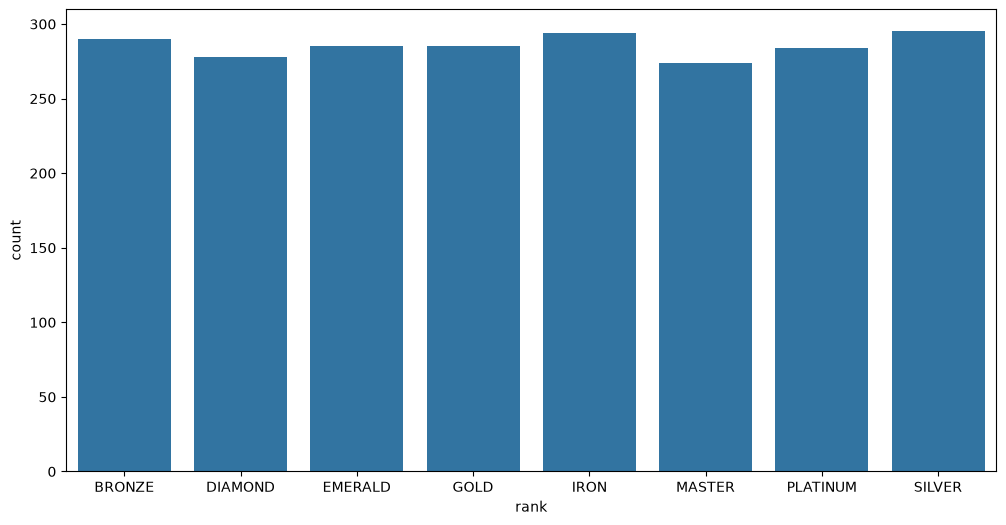

In [5]:
#Countplot de ranks (variable objetivo)
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x=data["rank"])
plt.show()

### Promedio de minionsKilled según el rank

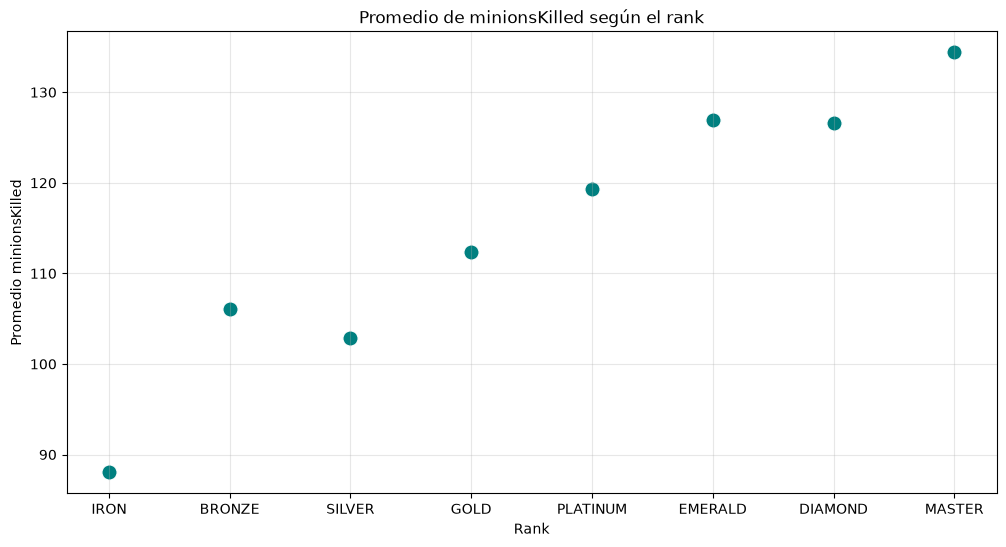

In [6]:
rank_order = ["IRON", "BRONZE", "SILVER", "GOLD", "PLATINUM", "EMERALD", "DIAMOND", "MASTER"]


# Promedio de minionsKilled agrupado por rank, respetando el orden
avg_minions = (
    data.groupby("rank")["minionsKilled"]
    .mean()
    .reindex(rank_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=avg_minions, x="rank", y="minionsKilled", s=120, color="teal")
plt.title("Promedio de minionsKilled según el rank")
plt.xlabel("Rank")
plt.ylabel("Promedio minionsKilled")
plt.grid(True, alpha=0.3)
plt.show()

### Tiempo promedio por partida según el rank

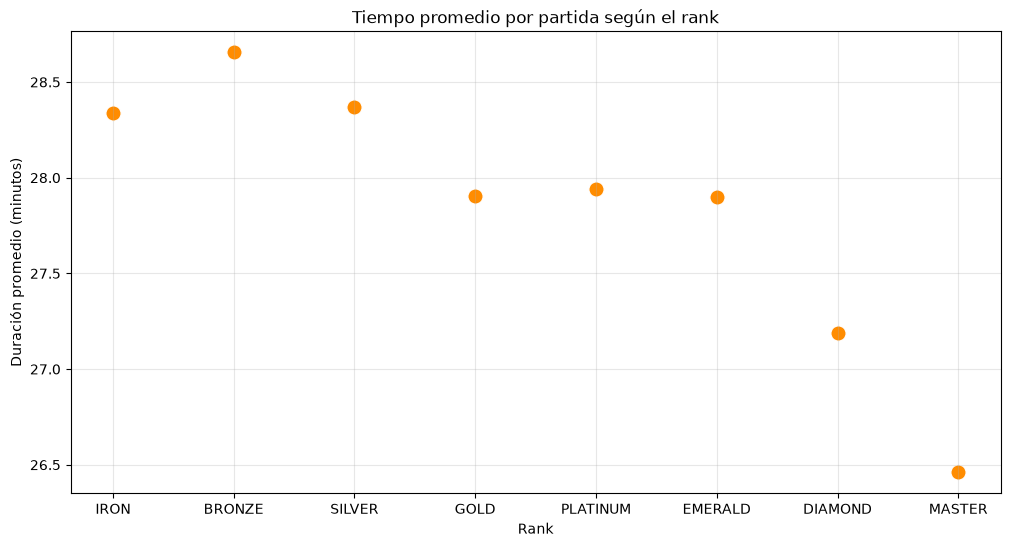

In [7]:
# Tiempo promedio por partida (gameDuration, en minutos) por rank

# Promedio de gameDuration agrupado por rank, respetando el orden
avg_duration = (
    data.groupby("rank")["gameDuration"]
    .mean()
    .reindex(rank_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=avg_duration, x="rank", y="gameDuration", s=120, color="darkorange")
plt.title("Tiempo promedio por partida según el rank")
plt.xlabel("Rank")
plt.ylabel("Duración promedio (minutos)")
plt.grid(True, alpha=0.3)
plt.show()

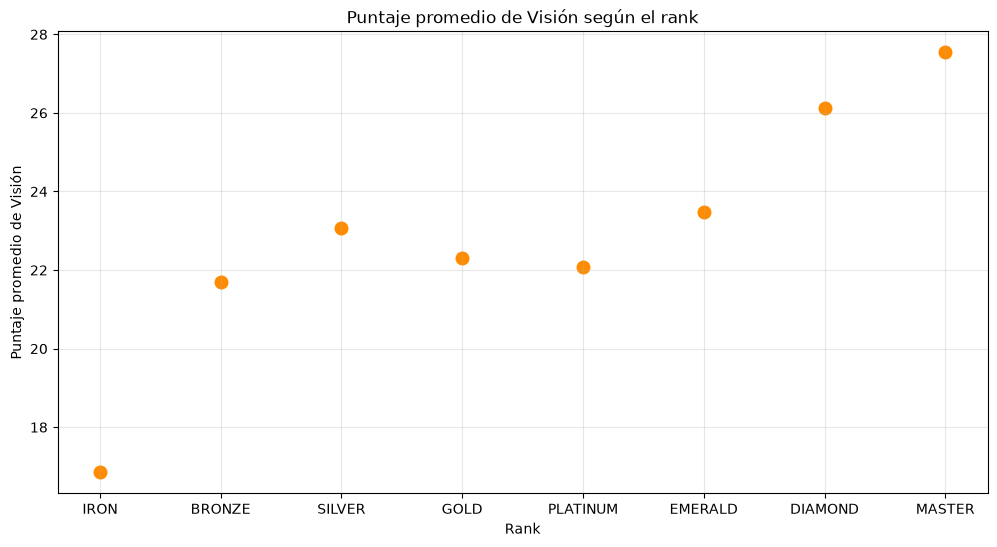

In [8]:
# Tiempo promedio por partida (gameDuration, en minutos) por rank

# Promedio de VisionScore agrupado por rank, respetando el orden
avg_vision_score = (
    data.groupby("rank")["visionScore"]
    .mean()
    .reindex(rank_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=avg_vision_score, x="rank", y="visionScore", s=120, color="darkorange")
plt.title("Puntaje promedio de Visión según el rank")
plt.xlabel("Rank")
plt.ylabel("Puntaje promedio de Visión")
plt.grid(True, alpha=0.3)
plt.show()

## Consideraciones

Dado que el rango de los jugadores es de vital importancia para este estudio, se pasará esta variable a valores numéricos que respeten el orden de los rangos dentro del videojuego


In [9]:
# Orden correcto de ranks
rank_order = {
    "IRON": 0,
    "BRONZE": 1,
    "SILVER": 2,
    "GOLD": 3,
    "PLATINUM": 4,
    "EMERALD": 5,
    "DIAMOND": 6,
    "MASTER": 7,
    "GRANDMASTER": 8,
    "CHALLENGER": 9
}

# Codificar rank
data["rank_encoded"] = data["rank"].map(rank_order)

# Verificar resultado
print(data[["rank", "rank_encoded"]])

        rank  rank_encoded
0     BRONZE             1
1     BRONZE             1
2     BRONZE             1
3     BRONZE             1
4     BRONZE             1
...      ...           ...
2280  SILVER             2
2281  SILVER             2
2282  SILVER             2
2283  SILVER             2
2284  SILVER             2

[2285 rows x 2 columns]


A su vez, el nombre de los jugadores, correspondiente a la variable "summonerName", no es relevante en este estudio, ya que no ofrece información relacionada con el rango del propio jugador, asi que se elimina del dataset

In [10]:
#Eliminar summonerName
data = data.drop(columns=["summonerName"])
data

,summonerLevel,rank,wins,losses,winRate,kills,deaths,assists,prefLane,campsKilled,...,goldEarned,turretTakedowns,visionScore,dragonKills,longestTimeSpentLiving,totalDamageDealt,totalDamageTaken,gameDuration,gameStart,rank_encoded
0,712,BRONZE,13,12,0.52,3.20,6.72,15.36,SUPPORT,0.80,...,8982.20,1,45.56,0,506.96,48651.12,544240,28.566667,7.216000,1
1,199,BRONZE,12,13,0.48,8.36,5.72,14.44,SUPPORT,1.72,...,11866.56,0,29.96,0,494.00,78143.68,441284,24.580667,16.400000,1
2,340,BRONZE,11,14,0.44,8.20,9.00,7.88,TOP,5.16,...,13236.60,1,19.96,0,438.64,150665.56,743065,30.250667,16.724667,1
3,61,BRONZE,12,13,0.48,8.60,7.52,8.20,ADC,9.36,...,13367.08,2,25.36,0,558.36,170517.52,594545,30.931333,17.265333,1
4,124,BRONZE,8,17,0.32,5.24,7.32,8.76,JUNGLE,53.56,...,11655.24,0,21.28,0,563.40,152541.04,652545,29.800000,13.505333,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2280,516,SILVER,12,13,0.48,7.36,6.04,12.92,MIDDLE,1.80,...,12483.88,2,36.24,0,634.64,124161.88,540583,31.024000,15.213333,2
2281,241,SILVER,9,16,0.36,7.40,7.96,11.68,NONE,2.28,...,12285.04,1,9.44,0,346.32,97369.36,521546,22.320000,14.589333,2
2282,312,SILVER,15,10,0.60,9.20,8.04,8.36,MIDDLE,75.16,...,13425.88,1,14.48,0,374.04,196456.52,809734,28.762667,15.082667,2
2283,520,SILVER,9,16,0.36,6.36,7.76,7.92,NONE,27.48,...,14513.68,1,24.40,0,404.08,143844.24,826660,29.032000,14.207333,2


A su vez, se codificará el prefLane, ya que es una variable relevante para el estudio, dado que el rol influye en las estadisticas de los jugadores dentro del juego, por ejemplo, un jugador de Support no tendrá muchos asesinatos ni minions asesinados, ya que no está contemplado dentro de su trabajo dentro del rol, pero si tendrá más puntuación de vision que los demás, o también, roles como Mid y Adc obtienen más kills y daño inflingido que los demas roles

In [11]:
data = pd.get_dummies(data, columns=["prefLane"], dtype=int)
data

,summonerLevel,rank,wins,losses,winRate,kills,deaths,assists,campsKilled,minionsKilled,...,totalDamageTaken,gameDuration,gameStart,rank_encoded,prefLane_ADC,prefLane_JUNGLE,prefLane_MIDDLE,prefLane_NONE,prefLane_SUPPORT,prefLane_TOP
0,712,BRONZE,13,12,0.52,3.20,6.72,15.36,0.80,50.32,...,544240,28.566667,7.216000,1,0,0,0,0,1,0
1,199,BRONZE,12,13,0.48,8.36,5.72,14.44,1.72,47.40,...,441284,24.580667,16.400000,1,0,0,0,0,1,0
2,340,BRONZE,11,14,0.44,8.20,9.00,7.88,5.16,186.16,...,743065,30.250667,16.724667,1,0,0,0,0,0,1
3,61,BRONZE,12,13,0.48,8.60,7.52,8.20,9.36,190.00,...,594545,30.931333,17.265333,1,1,0,0,0,0,0
4,124,BRONZE,8,17,0.32,5.24,7.32,8.76,53.56,97.76,...,652545,29.800000,13.505333,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2280,516,SILVER,12,13,0.48,7.36,6.04,12.92,1.80,138.36,...,540583,31.024000,15.213333,2,0,0,1,0,0,0
2281,241,SILVER,9,16,0.36,7.40,7.96,11.68,2.28,98.52,...,521546,22.320000,14.589333,2,0,0,0,1,0,0
2282,312,SILVER,15,10,0.60,9.20,8.04,8.36,75.16,87.72,...,809734,28.762667,15.082667,2,0,0,1,0,0,0
2283,520,SILVER,9,16,0.36,6.36,7.76,7.92,27.48,103.88,...,826660,29.032000,14.207333,2,0,0,0,1,0,0


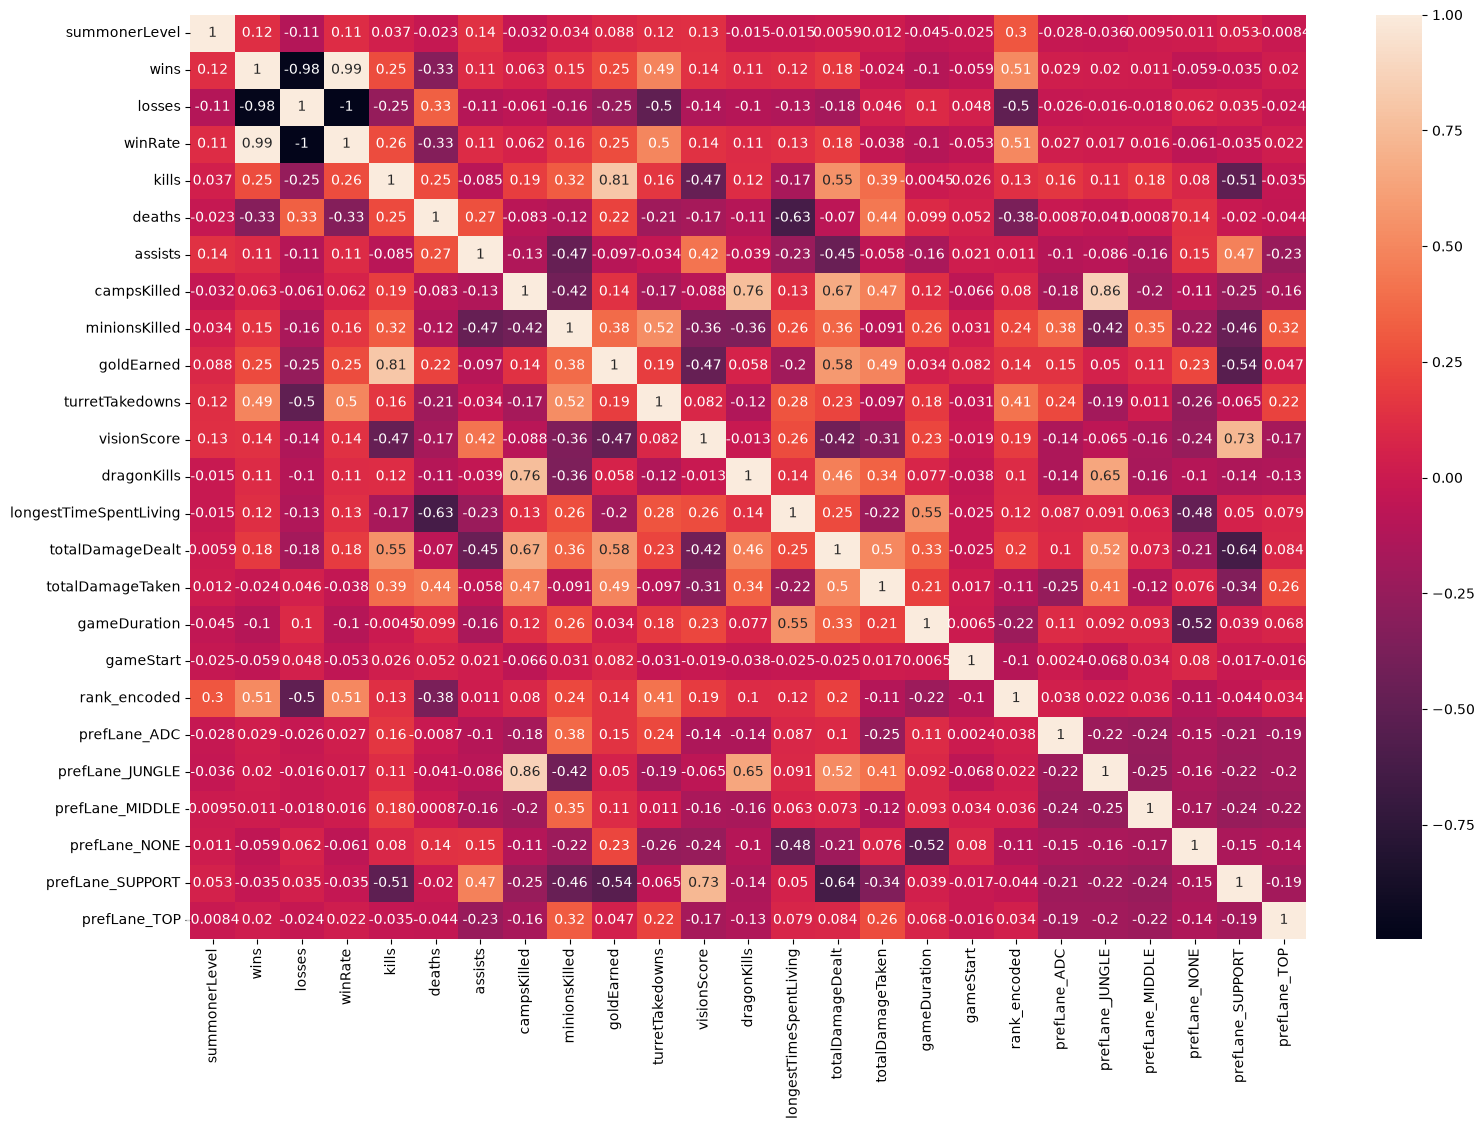

In [12]:
plt.figure(figsize=(18, 12))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()


De la matriz de correlacion podemos observar varias variables que se relacionan entre si, como pueden ser el "winRate" con las "wins", esto debido a que el winRate es una estadística proveniente de la tasa de victorias dentro del total de partidas jugadas, por lo que a mayor cantidad de victorias, mayor será el winRate. De la misma manera, las "wins" y las "losses" tienen una correlacion inversa, ya que si en un total de 25 partidas, a mayor cantidad de wins, menores serán las losses.

También se tiene la correlación entre las "kills" con el "totalDamageDealt" y el "goldEarned", lo cual viene de que a mayor cantidad de asesinatos dentro de la partida, significa que el jugador inflingió más daño para lograr esas kills, y por lo tanto, que obtuvo una mayor cantidad de oro proveniente de las mismas.

Por otro lado, las variables de "campsKilled" y "dragonKills" están también relacionadas, y esto es en el caso del rol de Jungla, el cual obtiene recursos de los monstruos de la jungla y se encarga de asesinar objetivos neutrales dentro del mapa, como pueden ser Dragones, el Heraldo, el Barón, etc.

Finalmente, las variables con más relacion con nuestra variable objetivo "rank_encoded" son el "winRate" y las "wins", lo cual concuerda con la realidad, ya que para subir dentro del ranking clasificatorio, se deben ganar una mayor cantidad de partidas, y por consecuente, "losses" tiene una correlación negativa. También estan las variables de "turretTakedowns" y "minionsKilled" dado que para ganar una partida se deben destruir las torres para llegar al Nexo, y para hacer esto, se deben empujar las oleadas matando minions. Otra variable con correlación negativa es la de "deaths", lo cual nos indica que para llegar a rangos más altos, es vital no morir dentro de las partidas, ya que al hacer esto, se estan cediendo recursos al equipo enemigo (oro y experiencia provenientes de la muerte del jugador) y se estan perdiendo recursos para el propio jugador ya que no puede obtenerlos si está muerto.

En conclusión, dadas las variables más influyentes dentro de "rank_encoded", podemos decir que para llegar a ELO's mas altos, lo más importante es ganar muchas más partidas de las que se pierden (winRate alto), y esto lo lograremos jugando campeones los cuales tengan facilidad para empujar oleadas y derribar torretas enemigas, y que tengan recursos para lograr escapar del equipo enemigo o sobrevivir, evitando morir demasiadas veces. Cabe recalcar que winRate siempre es afectado por variables externas al jugador, como el MMR (valor numérico que afecta al emparejamiento en partidas clasificatorias), los jugadores Trolls o AFK (inactivos) los cuales hacen más probable el perder las partidas, o el LAG, sin embargo, estos factores no se tomarán en cuenta para este estudio.

### Pipeline y Separación de datos

In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline import Pipeline

In [14]:
#Crear Pipeline para el Random Forest
pipeline = Pipeline([
    ('rf', RandomForestClassifier())
])
params_grid = {
    "rf__n_estimators":[100, 200, 300],
    "rf__criterion": ["gini", "entropy"],
    "rf__max_depth": [None, 10, 20, 30]
}

In [15]:
#Separar los datos entre estimadores y variable objetivo
X = data.drop(columns=["rank_encoded", "rank"])
y = data["rank_encoded"]

In [16]:
#Separar datos en testeo y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
grid_search = GridSearchCV(pipeline, params_grid, cv=5)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__criterion': ['gini', 'entropy'], 'rf__max_depth': [None, 10, ...], 'rf__n_estimators': [100, 200, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: i

In [17]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](8,)","[0,1,2,...,5,6,7]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['summonerLevel','wins','losses',...,'prefLane_NONE','prefLane_SUPPORT', 'prefLane_TOP']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'


### Entrenar modelo

In [18]:
model = RandomForestClassifier(

    n_estimators=300,
    max_depth=20,
    criterion='gini',
    random_state=42

)

In [19]:
#Entrenamiento
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [20]:
y_pred = model.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.4135667396061269


In [22]:
print("\nClassification Report:")

print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.77      0.70        57
           1       0.29      0.25      0.27        59
           2       0.24      0.22      0.23        60
           3       0.27      0.19      0.22        62
           4       0.23      0.30      0.26        50
           5       0.23      0.25      0.24        48
           6       0.48      0.34      0.40        65
           7       0.75      1.00      0.85        56

    accuracy                           0.41       457
   macro avg       0.39      0.42      0.40       457
weighted avg       0.40      0.41      0.40       457




Confusion Matrix:


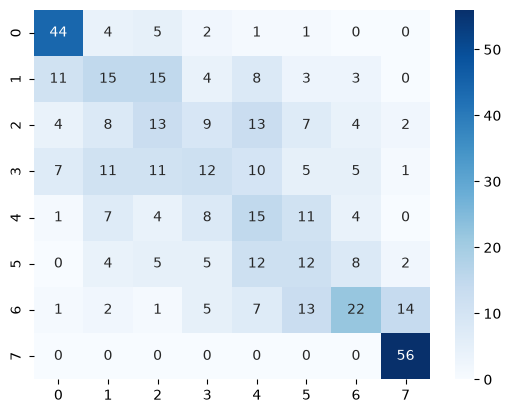

In [23]:
print("\nConfusion Matrix:")

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.show()

## Agrupación por rango
Debido a que con 8 clases la precisión se ve limitada. El problema de rangos similares como lo pueden ser GOLD y PLANTINIUM, son difiicles de separar y el 'winRate' calculado sobre las 25 partidas tiene mucha varianza entre si. Es decir depende de que tan bien y mal le haya ido al jugador en los ultimos juegos, no determina necesariamente su rango real. Aún asi los rank IRON y MASTER son mejor clasificados de acuerdo al *classification report*, pero los rangos intermedios son más problematicos.

Para obtener una predicción más útil agrupamos los 8 rangos en **3 tiers**:

- **Bajo (0):** IRON, BRONZE, SILVER
- **Medio (1):** GOLD, PLATINUM, EMERALD
- **Alto (2):** DIAMOND, MASTER

Esto replantea el problema y pretende elevar la precisión

In [24]:
# Agrupar los 8 rangos en 3 tiers
# Bajo: IRON(0), BRONZE(1), SILVER(2) -> 0
# Medio: GOLD(3), PLATINUM(4), EMERALD(5) -> 1
# Alto: DIAMOND(6), MASTER(7) -> 2
tier_map = {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2}
y_tier = data["rank_encoded"].map(tier_map)

tier_names = {0: "Bajo", 1: "Medio", 2: "Alto"}
print(y_tier.map(tier_names).value_counts())

rank_encoded
Bajo     879
Medio    854
Alto     552
Name: count, dtype: int64


In [25]:
# Separar datos usando el target por tiers (mismas features X)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X, y_tier, test_size=0.2, random_state=42, stratify=y_tier
)

# Entrenar Random Forest sobre los tiers
model_tier = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    criterion="gini",
    random_state=42
)
model_tier.fit(X_train_t, y_train_t)
y_pred_t = model_tier.predict(X_test_t)

In [26]:
# Evaluación del modelo por tiers
print("Accuracy (tiers):", accuracy_score(y_test_t, y_pred_t))
print("\nClassification Report (tiers):")
print(classification_report(y_test_t, y_pred_t, target_names=["Bajo", "Medio", "Alto"]))

Accuracy (tiers): 0.6761487964989059

Classification Report (tiers):
              precision    recall  f1-score   support

        Bajo       0.69      0.72      0.71       176
       Medio       0.59      0.61      0.60       171
        Alto       0.80      0.71      0.75       110

    accuracy                           0.68       457
   macro avg       0.70      0.68      0.69       457
weighted avg       0.68      0.68      0.68       457



Confusion Matrix (tiers):


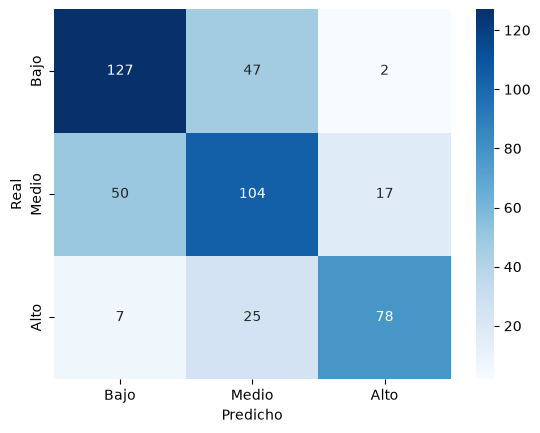

In [27]:
# Matriz de confusión por tiers
print("Confusion Matrix (tiers):")
sns.heatmap(
    confusion_matrix(y_test_t, y_pred_t),
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["Bajo", "Medio", "Alto"],
    yticklabels=["Bajo", "Medio", "Alto"]
)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

Se aprecia una mejora notable de resultados, lo cual tiende a predecir en que grupo o "ELO" esta cada jugador con una precisión proximada del 70%, por lo cual tener menos clases e incluir una agrupacion es una implementación idonea para este caso, ya que nos da un mayor acercamiento a que rango en pertenecería cierto jugador.

## Análisis de Componentes Principales (PCA)

El PCA reduce las variables a un conjunto menor de *componentes principales* (combinaciones lineales de las originales) que concentran la mayor varianza posible. Sirve para:

- Visualizar en 2D si los rangos se separan o se solapan.
- Ver cuántas componentes hacen falta para explicar la mayoría de la información.
- Identificar qué variables aportan más a cada componente (*loadings*).

Como las variables están en escalas muy distintas (por ejemplo `goldEarned` ~12000 vs `deaths` ~6), **es obligatorio estandarizar** antes de aplicar PCA.

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Estandarizar las features (media 0, desviación 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ajustar PCA con todas las componentes
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Número de componentes:", pca.n_components_)

Número de componentes: 24


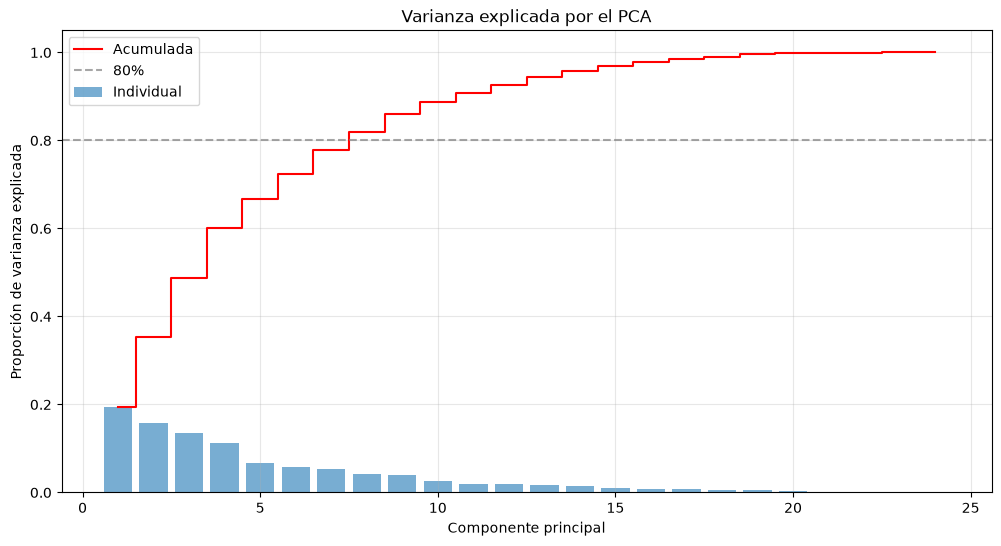

Se necesitan 8 componentes para explicar el 80% de la varianza


In [29]:
# Varianza explicada por componente (scree plot)
var_exp = pca.explained_variance_ratio_
var_acum = var_exp.cumsum()

plt.figure(figsize=(12, 6))
plt.bar(range(1, len(var_exp) + 1), var_exp, alpha=0.6, label="Individual")
plt.step(range(1, len(var_acum) + 1), var_acum, where="mid", color="red", label="Acumulada")
plt.axhline(0.8, color="gray", linestyle="--", alpha=0.7, label="80%")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza explicada")
plt.title("Varianza explicada por el PCA")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

n80 = (var_acum < 0.8).sum() + 1
print(f"Se necesitan {n80} componentes para explicar el 80% de la varianza")

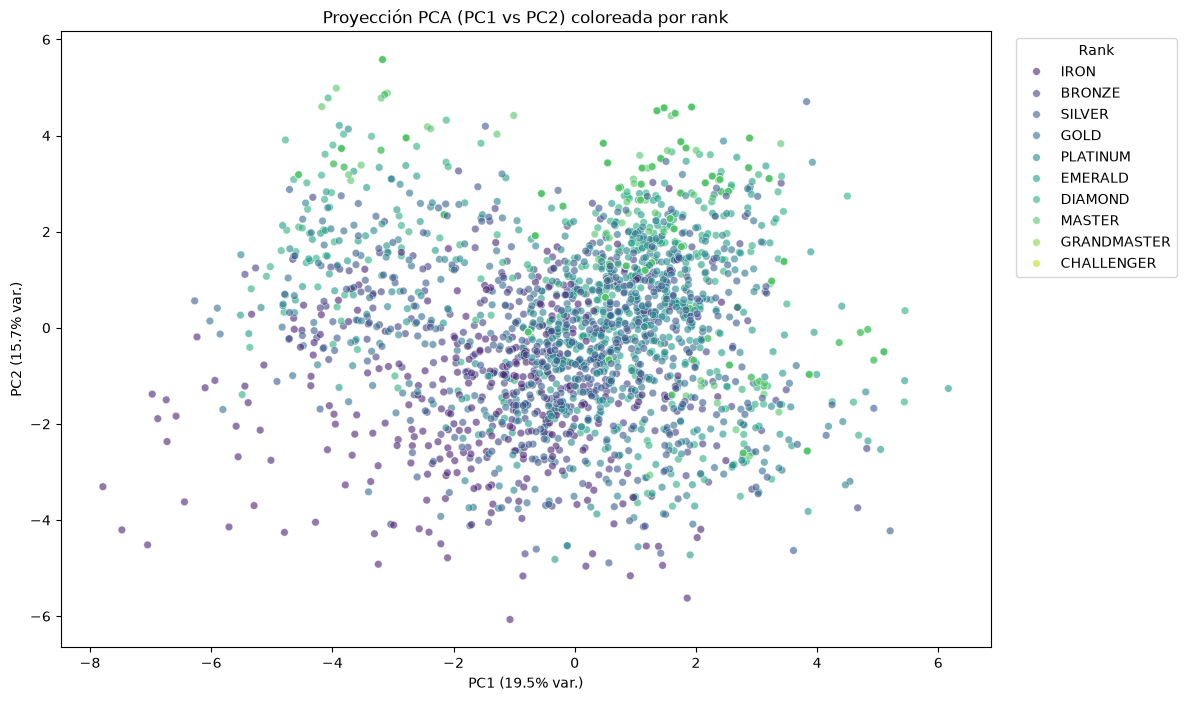

In [30]:
# Proyección de los jugadores en las 2 primeras componentes, coloreado por rank
plt.figure(figsize=(12, 8))
sc = sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=data["rank"], hue_order=rank_order,
    palette="viridis", alpha=0.6, s=30
)
plt.xlabel(f"PC1 ({var_exp[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.1f}% var.)")
plt.title("Proyección PCA (PC1 vs PC2) coloreada por rank")
plt.legend(title="Rank", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [31]:
# Loadings: contribución de cada variable a PC1 y PC2
loadings = pd.DataFrame(
    pca.components_[:2].T,
    columns=["PC1", "PC2"],
    index=X.columns
)

# Variables más influyentes en PC1
print("Top variables en PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(8))
print("\nTop variables en PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head(8))

Top variables en PC1:
totalDamageDealt    0.412735
goldEarned          0.336936
prefLane_SUPPORT    0.331134
kills               0.330771
totalDamageTaken    0.231309
visionScore         0.229991
campsKilled         0.224032
winRate             0.218943
Name: PC1, dtype: float64

Top variables en PC2:
winRate             0.351026
losses              0.350850
wins                0.347225
turretTakedowns     0.336448
totalDamageTaken    0.280791
prefLane_JUNGLE     0.255387
campsKilled         0.254833
deaths              0.254547
Name: PC2, dtype: float64


La proyección PC1 vs PC2 muestra un fuerte solapamiento entre rangos, lo que confirma por qué la clasificación en 8 clases es difícil: las dos primeras componentes no separan limpiamente los rangos intermedios. Esto concuerda con la baja precisión del modelo (~0.42) y refuerza la decisión de agrupar en tiers.

## Análisis por rol (prefLane)

El PCA mostró que la mayor fuente de varianza es el **rol** del jugador, no su rango. Esto tiene sentido: un Support y un ADC tienen estadísticas muy distintas aunque estén en el mismo rango. Por eso, analizar todo junto mezcla efectos del rol con efectos de la habilidad.

POr tanto, se prefiere estudiar cada rol por separado para responder: **¿qué variables predicen el rango dentro de cada rol?**


Utilizamos el dataset original para recuperar la columna `prefLane` y le añadimos los rangos condificados.

In [32]:
import warnings

# Recargar CSV original para tener prefLane como categoría
df_rol = pd.read_csv("./LeaguePlayerStats.csv")
df_rol["rank_encoded"] = df_rol["rank"].map({
    "IRON": 0, "BRONZE": 1, "SILVER": 2, "GOLD": 3,
    "PLATINUM": 4, "EMERALD": 5, "DIAMOND": 6, "MASTER": 7
})

print("Cantidad de jugadores por rol:")
print(df_rol["prefLane"].value_counts())

Cantidad de jugadores por rol:
prefLane
MIDDLE     501
JUNGLE     422
ADC        400
SUPPORT    396
TOP        345
NONE       221
Name: count, dtype: int64


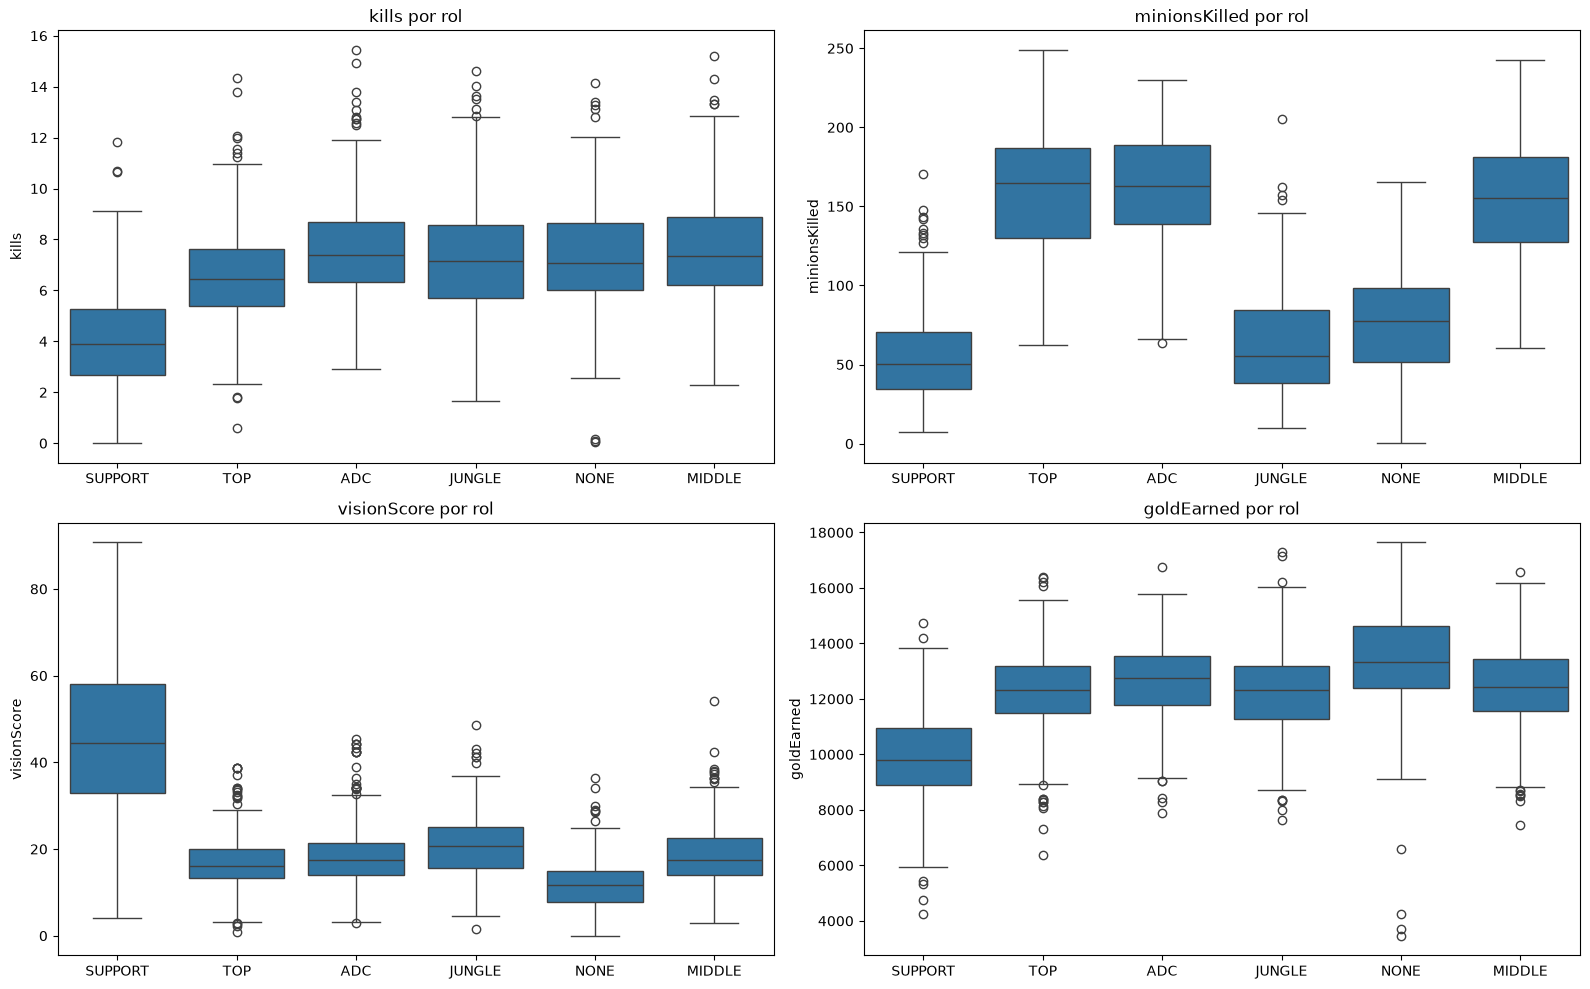

In [33]:
# Distribución de estadísticas clave por rol (valida que el rol cambia las stats)
stats_clave = ["kills", "minionsKilled", "visionScore", "goldEarned"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flat, stats_clave):
    sns.boxplot(data=df_rol, x="prefLane", y=col, ax=ax)
    ax.set_title(f"{col} por rol")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

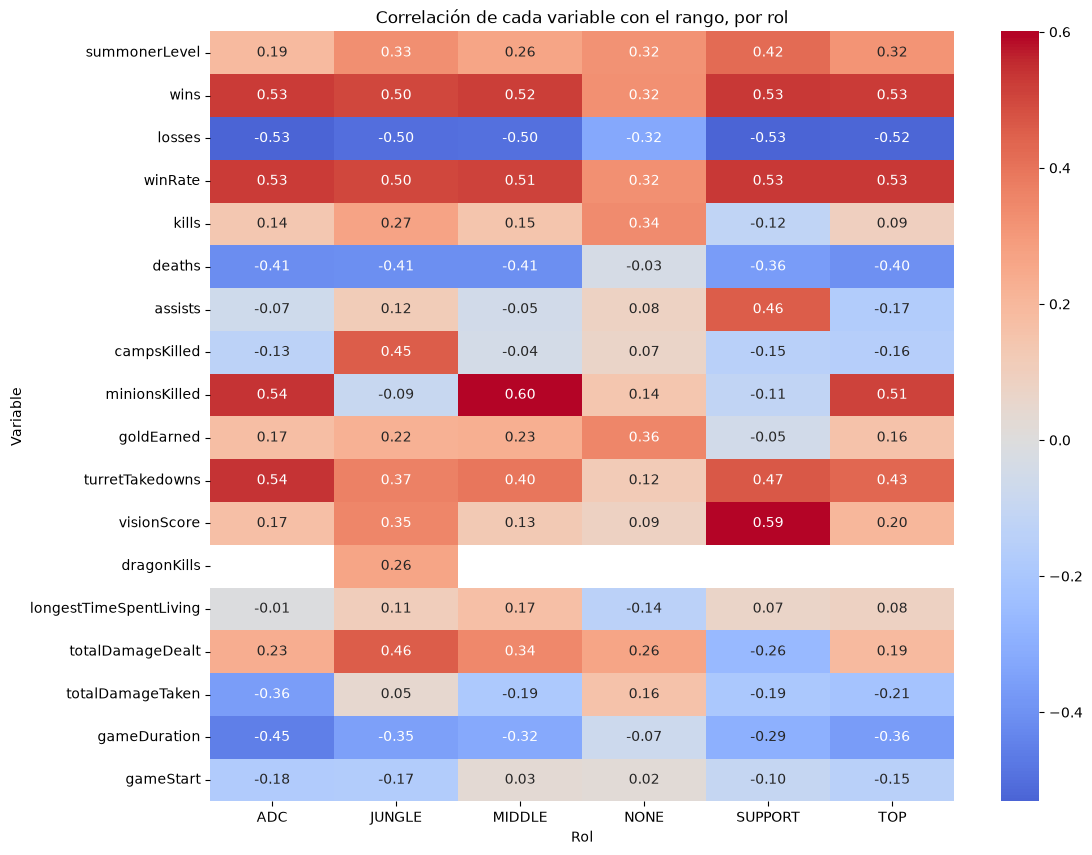

In [34]:
# Correlación de cada variable con rank_encoded, calculada por separado para cada rol
num_cols = df_rol.select_dtypes("number").columns.drop("rank_encoded")

corr_por_rol = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # ignora vars de varianza cero (ej. dragonKills en algún rol)
    for rol, g in df_rol.groupby("prefLane"):
        corr_por_rol[rol] = g[num_cols].corrwith(g["rank_encoded"])

corr_df = pd.DataFrame(corr_por_rol)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación de cada variable con el rango, por rol")
plt.xlabel("Rol")
plt.ylabel("Variable")
plt.show()

In [35]:
# Para cada rol, las 5 variables más correlacionadas (en valor absoluto) con el rango
for rol in corr_df.columns:
    top = corr_df[rol].abs().sort_values(ascending=False).head(5)
    print(f"\n{rol}:")
    for var, val in top.items():
        print(f"  {var:20s} {corr_df.loc[var, rol]:+.2f}")


ADC:
  minionsKilled        +0.54
  turretTakedowns      +0.54
  winRate              +0.53
  wins                 +0.53
  losses               -0.53

JUNGLE:
  winRate              +0.50
  wins                 +0.50
  losses               -0.50
  totalDamageDealt     +0.46
  campsKilled          +0.45

MIDDLE:
  minionsKilled        +0.60
  wins                 +0.52
  winRate              +0.51
  losses               -0.50
  deaths               -0.41

NONE:
  goldEarned           +0.36
  kills                +0.34
  losses               -0.32
  wins                 +0.32
  winRate              +0.32

SUPPORT:
  visionScore          +0.59
  wins                 +0.53
  winRate              +0.53
  losses               -0.53
  turretTakedowns      +0.47

TOP:
  winRate              +0.53
  wins                 +0.53
  losses               -0.52
  minionsKilled        +0.51
  turretTakedowns      +0.43


### Conclusiones del análisis por rol

El análisis confirma la hipótesis del PCA: **las variables que más influyen en el rango dependen del rol**.

- **Variables transversales:** `winRate`, `wins` y `losses` aparecen entre las más correlacionadas en *todos* los roles. Ganar partidas importa independientemente de que rol juegues.
- **SUPPORT:** la variable más influyente es `visionScore` (~0.59), muy por encima de los demás roles. Coincide con que el trabajo del support es controlar la visión del mapa.
- **MIDDLE, ADC y TOP:** destaca `minionsKilled` (~0.5–0.6), reflejando que el control de oleadas y la economía son clave para estos roles de carril.
- **JUNGLE:** además del winRate, pesa `totalDamageDealt`, asociado al impacto del jungla en peleas y objetivos.
- **NONE:** correlaciones más débiles (rol indefinido o datos mezclados), por lo que es menos informativo. Probablemente jugadores con Autofill (rol aleatorio) que no les importe mucho apuntar a un mejor rendimiento especializado